In [6]:

!pip install imbalanced-learn

In [7]:
# ── Libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from imblearn.over_sampling import SMOTE

In [8]:

# STEP 1 — LOAD DATA
# ============================================================

train_df = pd.read_csv("/content/churn-bigml-80.csv")
test_df  = pd.read_csv("/content/churn-bigml-20.csv")

print("=" * 55)
print("TRAIN shape:", train_df.shape)
print("TEST  shape:", test_df.shape)
print("\nTrain Churn Distribution:")
print(train_df['Churn'].value_counts(normalize=True).mul(100).round(1))

TRAIN shape: (2666, 20)
TEST  shape: (667, 20)

Train Churn Distribution:
Churn
False    85.4
True     14.6
Name: proportion, dtype: float64


In [9]:
# STEP 2 — DROP USELESS COLUMNS
# ============================================================
# Reasons:
#   State, Area code    → No business signal (location irrelevant)
#   Account length      → 0.000 correlation with Churn
#   *Charge columns     → Exact duplicate of Minutes × fixed rate
#   Number vmail msgs   → Same info as Voice mail plan (72.5% zeros)

DROP_COLS = [
    'State',
    'Area code',
    'Account length',
    'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge',
    'Number vmail messages'
]

train_df.drop(columns=DROP_COLS, inplace=True)
test_df.drop(columns=DROP_COLS,  inplace=True)

print("\nColumns after drop:", train_df.shape[1])
print(train_df.columns.tolist())


Columns after drop: 12
['International plan', 'Voice mail plan', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']


In [11]:
train_df.head()

,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,No,Yes,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,No,Yes,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,No,No,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,Yes,No,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,Yes,No,166.7,113,148.3,122,186.9,121,10.1,3,3,False


In [12]:
# International plan & Voice mail plan → 'Yes'/'No' → 1/0
YESNO_COLS = ['International plan', 'Voice mail plan']
for col in YESNO_COLS:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})
    test_df[col]  = test_df[col].map({'Yes': 1, 'No': 0})

# Churn → True/False → 1/0
train_df['Churn'] = train_df['Churn'].astype(int)
test_df['Churn']  = test_df['Churn'].astype(int)

print("Encoding done ✅")
print(train_df[['International plan', 'Voice mail plan', 'Churn']].head(3))

Encoding done ✅
   International plan  Voice mail plan  Churn
0                   0                1      0
1                   0                1      0
2                   0                0      0


In [13]:
# ============================================================
# STEP 4 — OUTLIER REMOVAL (Z-Score, threshold = 3)
# ============================================================
# Applied only on numeric feature columns, NOT on target

NUMERIC_COLS = train_df.select_dtypes(include=np.number).columns.tolist()
NUMERIC_COLS.remove('Churn')  # never touch the target

before = len(train_df)
z_scores = np.abs(stats.zscore(train_df[NUMERIC_COLS]))
train_df = train_df[(z_scores < 3).all(axis=1)]
after = len(train_df)

print(f"\nOutlier Removal: {before} → {after} rows ({before - after} removed)")


Outlier Removal: 2666 → 2544 rows (122 removed)


In [14]:
train_df.shape

(2544, 12)

In [15]:
# STEP 5 — SPLIT FEATURES & TARGET
# ============================================================

X_train_full = train_df.drop(columns=['Churn'])
y_train_full = train_df['Churn']

X_test  = test_df.drop(columns=['Churn'])
y_test  = test_df['Churn']

print("\nFeature columns:", X_train_full.columns.tolist())
print("X_train:", X_train_full.shape, "| X_test:", X_test.shape)


Feature columns: ['International plan', 'Voice mail plan', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls']
X_train: (2544, 11) | X_test: (667, 11)


In [16]:
# STEP 6 — TRAIN / VALIDATION SPLIT
# ============================================================
# Split train data → 80% train, 20% validation
# Stratify = ensure same churn ratio in both splits

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"\nSplit → Train: {X_train.shape}, Val: {X_val.shape}")


Split → Train: (2035, 11), Val: (509, 11)


In [17]:
# ============================================================
# STEP 7 — FEATURE SCALING (StandardScaler)
# ============================================================
# Fit ONLY on X_train → transform val & test
# Reason: Avoid data leakage from val/test into training

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done ✅")


Scaling done ✅


In [18]:
# STEP 8 — HANDLE IMBALANCED DATA (SMOTE)
# ============================================================
# Churn=True only 14.6% → SMOTE creates synthetic minority samples

print("\nBefore SMOTE:", pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("After  SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())


Before SMOTE: {0: 1750, 1: 285}
After  SMOTE: {0: 1750, 1: 1750}


In [19]:
# STEP 9 — TRAIN 3 MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

val_results = {}

print("\n" + "=" * 55)
print("VALIDATION RESULTS")
print("=" * 55)

for name, model in models.items():
    # Train
    model.fit(X_train_sm, y_train_sm)

    # Predict on validation set
    y_pred     = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

    # Metrics
    f1  = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)

    val_results[name] = {'f1': f1, 'auc': auc, 'model': model}

    print(f"\n📌 {name}")
    print(f"   F1 Score : {f1:.4f}")
    print(f"   ROC-AUC  : {auc:.4f}")
    print(classification_report(y_val, y_pred,
                                target_names=['No Churn', 'Churn']))


VALIDATION RESULTS

📌 Logistic Regression
   F1 Score : 0.4483
   ROC-AUC  : 0.7943
              precision    recall  f1-score   support

    No Churn       0.95      0.75      0.84       438
       Churn       0.32      0.73      0.45        71

    accuracy                           0.75       509
   macro avg       0.63      0.74      0.64       509
weighted avg       0.86      0.75      0.78       509


📌 Random Forest
   F1 Score : 0.7826
   ROC-AUC  : 0.9033
              precision    recall  f1-score   support

    No Churn       0.96      0.97      0.97       438
       Churn       0.81      0.76      0.78        71

    accuracy                           0.94       509
   macro avg       0.88      0.87      0.87       509
weighted avg       0.94      0.94      0.94       509


📌 Gradient Boosting
   F1 Score : 0.7397
   ROC-AUC  : 0.9076
              precision    recall  f1-score   support

    No Churn       0.96      0.95      0.96       438
       Churn       0.72      0

In [20]:
# ============================================================
# STEP 10 — PICK BEST MODEL (by F1 Score)
# ============================================================

best_name  = max(val_results, key=lambda x: val_results[x]['f1'])
best_model = val_results[best_name]['model']

print("=" * 55)
print(f"✅ Best Model: {best_name}")
print(f"   F1 Score : {val_results[best_name]['f1']:.4f}")
print(f"   ROC-AUC  : {val_results[best_name]['auc']:.4f}")

✅ Best Model: Random Forest
   F1 Score : 0.7826
   ROC-AUC  : 0.9033


In [21]:
# STEP 11 — FINAL TEST on churn-20.csv (Unseen Data)
# ============================================================

print("\n" + "=" * 55)
print("FINAL TEST — churn-bigml-20.csv")
print("=" * 55)

y_test_pred       = best_model.predict(X_test_scaled)
y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

test_f1  = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"\nFinal F1 Score : {test_f1:.4f}")
print(f"Final ROC-AUC  : {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=['No Churn', 'Churn']))


FINAL TEST — churn-bigml-20.csv

Final F1 Score : 0.7676
Final ROC-AUC  : 0.9113

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.97      0.96       572
       Churn       0.79      0.75      0.77        95

    accuracy                           0.94       667
   macro avg       0.87      0.86      0.87       667
weighted avg       0.93      0.94      0.93       667



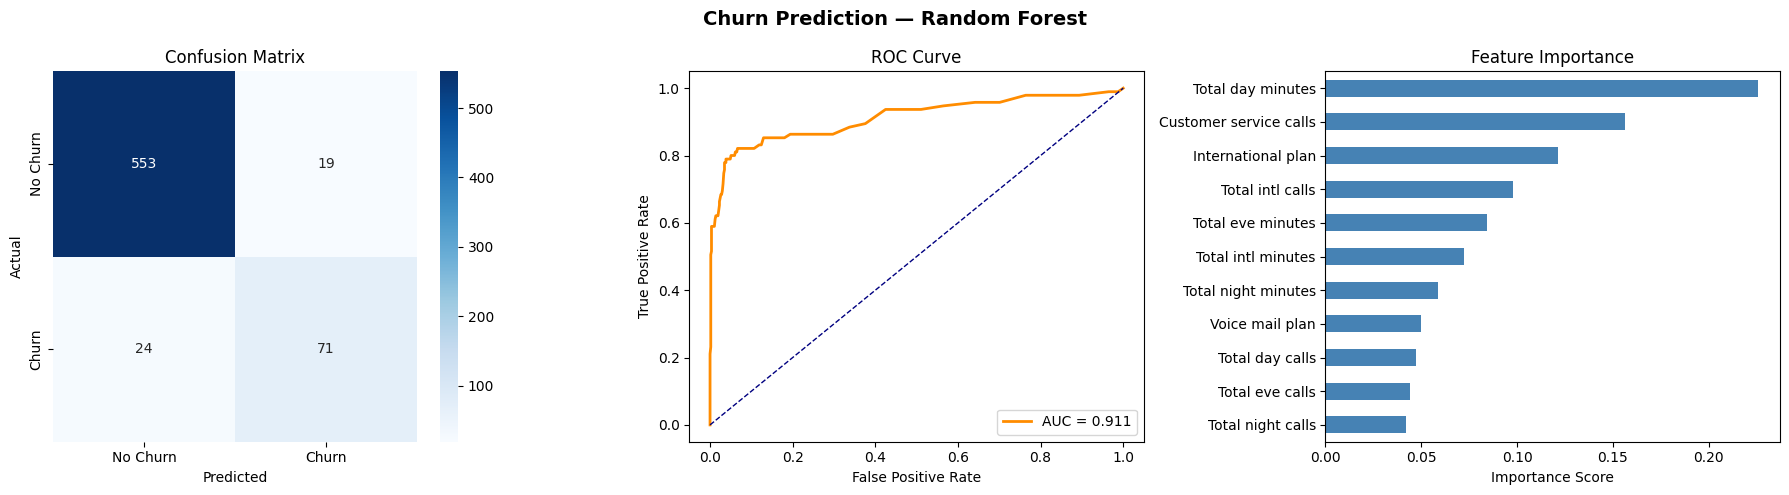


Plot saved → churn_results.png ✅


In [22]:
# ============================================================
# STEP 12 — VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Churn Prediction — {best_name}', fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix ─────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── Plot 2: ROC Curve ────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# ── Plot 3: Feature Importance (Random Forest only) ──────
if best_name == "Random Forest":
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
    axes[2].set_title('Feature Importance')
    axes[2].set_xlabel('Importance Score')
else:
    # For other models — show model comparison bar chart
    names = list(val_results.keys())
    f1s   = [val_results[n]['f1']  for n in names]
    aucs  = [val_results[n]['auc'] for n in names]

    x = np.arange(len(names))
    axes[2].bar(x - 0.2, f1s,  0.4, label='F1',      color='steelblue')
    axes[2].bar(x + 0.2, aucs, 0.4, label='ROC-AUC', color='darkorange')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(names, rotation=10)
    axes[2].set_title('Model Comparison')
    axes[2].legend()

plt.tight_layout()
plt.savefig('churn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved → churn_results.png ✅")



In [23]:
# ============================================================
# STEP 13 — FEATURE IMPORTANCE (Always show — regardless of model)
# ============================================================

if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)
else:
    # Logistic Regression — use coefficients
    feat_imp = pd.Series(
        np.abs(best_model.coef_[0]),
        index=X_train.columns
    ).sort_values(ascending=False)

print("\n" + "=" * 55)
print("FEATURE IMPORTANCE RANKING")
print("=" * 55)
print(feat_imp.round(4).to_string())


FEATURE IMPORTANCE RANKING
Total day minutes         0.2260
Customer service calls    0.1563
International plan        0.1213
Total intl calls          0.0979
Total eve minutes         0.0844
Total intl minutes        0.0724
Total night minutes       0.0586
Voice mail plan           0.0500
Total day calls           0.0473
Total eve calls           0.0441
Total night calls         0.0418


In [24]:
# ============================================================
# STEP 14 — BUSINESS INSIGHT SUMMARY
# ============================================================

print("\n" + "=" * 55)
print("BUSINESS INSIGHTS")
print("=" * 55)

top3 = feat_imp.head(3).index.tolist()
print(f"\nTop 3 Churn Drivers: {top3}")

# Customer Service Calls analysis
cs_col = 'Customer service calls'
if cs_col in train_df.columns:
    cs_churn = train_df.groupby(cs_col)['Churn'].mean().mul(100).round(1)
    print(f"\nChurn Rate by Customer Service Calls:")
    print(cs_churn.to_string())
    print("\n→ 4+ calls = HIGH churn risk! 🚨")

# International Plan analysis
ip_col = 'International plan'
if ip_col in train_df.columns:
    ip_churn = train_df.groupby(ip_col)['Churn'].mean().mul(100).round(1)
    print(f"\nChurn Rate by International Plan:")
    print(f"  No Plan (0): {ip_churn.get(0, 'N/A')}%")
    print(f"  Has Plan (1): {ip_churn.get(1, 'N/A')}%")

print("\n" + "=" * 55)
print("WORKFLOW COMPLETE ✅")
print("=" * 55)


BUSINESS INSIGHTS

Top 3 Churn Drivers: ['Total day minutes', 'Customer service calls', 'International plan']

Churn Rate by Customer Service Calls:
Customer service calls
0    14.0
1    10.2
2    10.5
3    10.7
4    48.4
5    59.6

→ 4+ calls = HIGH churn risk! 🚨

Churn Rate by International Plan:
  No Plan (0): 10.8%
  Has Plan (1): 42.8%

WORKFLOW COMPLETE ✅


In [26]:

import joblib

joblib.dump(best_model, 'churn_random_forest.pkl')

joblib.dump(scaler, 'churn_scaler.pkl')

print("Model saved! ✅")
from google.colab import files
files.download('churn_random_forest.pkl')
files.download('churn_scaler.pkl')

Model saved! ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>